In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import seaborn as sns  

from dotenv import load_dotenv; load_dotenv()


PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

TISSUE = "Striatum"
TYPE_DEG = "baseline_nebula" #PCA_nebula, baseline_nebula. gradient_score_nebula
ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured.h5ad"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "Group_name" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["age_of_death", "sex", "pct_counts_mt", "frac_intronic", "cohort",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "total_counts"

# # mitluple etst correction pvalue thr
# ALPHA_MULTIPLE_TEST = 0.05
# LOGFC_THR=0.1
# PVAL_THR=0.05

# Load

In [4]:
adata = sc.read_h5ad(ADATA_PATH)#, backed="r")
adata.obs.columns

###########################
#ATTENTION: use genenames for DEG
adata.var.index = adata.var["gene_symbol"]
###########################

# Calculate gene expression for low expressed gene
# Specific cell type

In [ ]:
CT_FOR_DEG_VARIABLE = "Group_name"
CT_TYPES = ["STRd D1 Matrix MSN", "STRv D1 MSN"]
CT_NAME = "D1_Matrix"
CT_COL = "ct_for_expe"
ZONE_COL = "zone"
LOGFC_THR = -1
PADJ_THR = 0.05

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

controls = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].copy()

# all cell types present in controls
all_ct = controls.obs[CT_FOR_DEG_VARIABLE].unique()

detection_rates = {}
for ct in all_ct:
    ct_cells = controls[controls.obs[CT_FOR_DEG_VARIABLE] == ct]
    X = ct_cells.X
    if sp.issparse(X): X = X.toarray()
    detection_rates[ct] = (X > 0).mean(axis=0)  # fraction of cells expressing each gene, a binary matrix where 1 = gene detected in that cell, 0 = not

# fraction of cells of that type where the gene was detected at least once. 
# This is detection rate, not mean counts,
detection_df = pd.DataFrame(detection_rates, index=controls.var_names)
detection_df.head()

,Astrocyte,OPC,VLMC,ImAstro,SMC,Endo,Pericyte,Ependymal,T cells,B cells,...,GPi Shell,OB Dopa-GABA,SN EBF2 GABA,Oligo OPALIN,SN SEMA5A GABA,GPe SOX6-CTXND1 GABA,STR Cholinergic GABA,GPin-BF Cholinergic GABA,COP,Oligo PLEKHG1
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,0.000395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.010526,0.0,...,0.0,0.0,0.0,0.000183,0.0,0.0,0.0,0.0,0.008333,0.000417
MIR1302-2HG,0.000263,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000131,0.0,0.0,0.0,0.0,0.000000,0.000000
FAM138A,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000026,0.0,0.0,0.0,0.0,0.000000,0.000000
ENSG00000290826,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
OR4F5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000


In [39]:
D1_CT_NAME = "STRd D1 Matrix MSN"  # adjust to exact name in your data
LOW_IN_D1_THR = 0.05       # detected in <5% of D1 cells
GLOBAL_LOW_THR = 0.05      # exclude if ALSO low in all other cell types

d1_detection = detection_df[D1_CT_NAME]
other_ct = [c for c in all_ct if c != D1_CT_NAME]
max_detection_others = detection_df[other_ct].max(axis=1)  # max across other CTs

# low in D1 AND expressed somewhere else (= specifically suppressed in D1)
low_d1_genes = detection_df[
    (d1_detection <= LOW_IN_D1_THR) &
    (max_detection_others > GLOBAL_LOW_THR)
].index.tolist()

print(f"Genes low in D1 but detected elsewhere: {len(low_d1_genes)}")

Genes low in D1 but detected elsewhere: 10271


In [ ]:
# use detection rate (not mean counts) as score — robust to sparsity
d1_all = adata[adata.obs[CT_FOR_DEG_VARIABLE].isin(CT_TYPES)].copy()
d1_all = d1_all[:, low_d1_genes].copy()

X = d1_all.X
if sp.issparse(X): X = X.toarray()

df_obs = d1_all.obs[[SAMPLE_VARIABLE, ZONE_COL, CONTRAST_VARIABLE]].copy()
df_obs["derepression_score"] = (X > 0).mean(axis=1)  # per-cell: % of low-genes that got detected

derepression = (
    df_obs.groupby([SAMPLE_VARIABLE, ZONE_COL, CONTRAST_VARIABLE])["derepression_score"]
    .mean()
    .reset_index()
)
derepression.head()

KeyError: "['zone'] not in index"

: 

In [ ]:
------

In [36]:
d1_controls = adata[
    (adata.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE) &
    (adata.obs[CT_FOR_DEG_VARIABLE].isin(CT_TYPES)) &
    (adata.obs["ct_for_deg"] == "Matrix") # curated cells
].copy()

print(d1_controls.shape)

(7600, 38601)


In [37]:
import numpy as np

# mean raw counts per gene across all control cells
mean_counts = np.array(d1_controls.X.mean(axis=0)).flatten()
gene_names = d1_controls.var_names

gene_expr = pd.DataFrame({
    "gene": gene_names,
    "mean_counts": mean_counts
}).set_index("gene").sort_values("mean_counts")

gene_expr.head(20)

,mean_counts
gene,
DEFA1B,0.0
ENSG00000260574,0.0
LINC01526,0.0
DEFB4B,0.0
DEFB108C,0.0
ENSG00000286354,0.0
ENSG00000267359,0.0
ENSG00000267035,0.0
ENSG00000267074,0.0


In [32]:
#make ad hoc col
adata.obs[CT_COL] = adata.obs[CT_FOR_DEG_VARIABLE].apply(lambda x: CT_NAME if x in CT_TYPES else x)

controls = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].copy()
                #     (adata.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE)  # controls
                # ].copy()
            #     (adata.obs[CT_FOR_DEG_VARIABLE].isin(CT)) & # only ct of interest
            #     (adata.obs["ct_for_deg"] == "Matrix") # curated cells
            # ].copy()



controls

NameError: name 'control' is not defined

In [33]:
mask = controls.obs[CT_COL] == CT_NAME

mean_ct   = np.asarray(controls[ mask].layers["log1p_norm"].mean(axis=0)).flatten()
mean_rest = np.asarray(controls[~mask].layers["log1p_norm"].mean(axis=0)).flatten()

df_low = pd.DataFrame({
    "gene":       controls.var_names,
    "mean_ct":    mean_ct,
    "mean_rest":  mean_rest,
}).query("mean_ct < @LOW_EXPR_THR and mean_rest > @REST_EXPR_THR")

print(f"Specifically low genes in {CT_NAME}: {len(df_low)}")
display(df_low.sort_values("mean_ct"))

UndefinedVariableError: local variable 'LOW_EXPR_THR' is not defined

In [ ]:
sc.tl.rank_genes_groups(
    controls_all_cells,
    groupby=CT_COL,
    groups=[CT_NAME],
    method='wilcoxon',
    reference='rest',
    pts=True
)

results = sc.get.rank_genes_groups_df(controls_all_cells, group=CT_NAME)

specifically_low = results[
    (results["logfoldchanges"] < LOGFC_THR) & # TAKE LOW GENES
    (results["pvals_adj"] < PADJ_THR) &
    (results["pct_nz_group"] < 0.1) &       # truly absent in this CT, pts: fraction of cells in the group expressing the gene
    (results["pct_nz_reference"] > 0.3)     # but present in other CTs, pts_rest: fraction of cells in all other groups expressing the gene

]

print(f"Specifically low genes in {CT_NAME}: {len(specifically_low)}")
display(specifically_low)


Specifically low genes in D1_Matrix: 100


,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
38349,LGR5,-37.165428,-2.816001,2.470314e-302,9.415145e-302,0.079937,0.303491
38351,MIR31HG,-37.317410,-2.677788,8.566934e-305,3.270618e-304,0.075989,0.301483
38365,LRP2,-39.070950,-3.364848,0.000000e+00,0.000000e+00,0.071154,0.307114
38370,LINC03002,-40.031227,-3.354983,0.000000e+00,0.000000e+00,0.074805,0.315973
38380,PROX1,-41.185043,-2.899582,0.000000e+00,0.000000e+00,0.074410,0.323455
...,...,...,...,...,...,...,...
38575,KIAA1755,-77.766495,-4.346801,0.000000e+00,0.000000e+00,0.083983,0.552907
38578,CECR2,-80.505020,-4.971150,0.000000e+00,0.000000e+00,0.080529,0.565245
38581,HTRA1,-82.212013,-4.667790,0.000000e+00,0.000000e+00,0.081911,0.576165
38583,NFIX,-83.152641,-4.392115,0.000000e+00,0.000000e+00,0.078851,0.582832


In [31]:
# ── Derepression score ────────────────────────────────────────────────────────
# Uses `specifically_low` from the previous cell:
# genes that are specifically silenced in CT (controls), identified via inverted rank_genes_groups.
#
# For each donor × zone (CT), compute the mean frequency of expression of those genes.
# High score = more of the normally-silenced genes are being expressed → derepression.

low_genes = specifically_low["names"].tolist()
genes_in_adata = [g for g in low_genes if g in adata.var_names]
gene_idx = adata.var_names.get_indexer(genes_in_adata)

#print(f"Using {len(genes_in_adata)} low genes from controls ({CT})")

records = []
for donor in adata.obs[SAMPLE_VARIABLE].unique():
    for ct in adata.obs[ZONE_COL].unique():
        mask = (adata.obs[SAMPLE_VARIABLE] == donor) & (adata.obs[ZONE_COL] == ct)
        cells = adata[mask]
        if cells.n_obs < 5:
            continue

        X_sub = cells.layers["log1p_norm"][:, gene_idx]
        # mean across genes of the per-gene expression frequency
        derep_score = float(np.array((X_sub > 0).mean(axis=0)).mean())

        records.append({
            "donor": donor,
            "ct": ct,
            "condition": cells.obs[CONTRAST_VARIABLE].iloc[0],
            "n_cells": cells.n_obs,
            "derepression_score": derep_score,
        })

derep_df = pd.DataFrame(records)

# ── Plot: derepression score per condition, per zone ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ct_order = (
    derep_df.groupby("ct")["derepression_score"].mean()
    .sort_values(ascending=False).index.tolist()
)
sns.boxplot(
    data=derep_df, x="ct", y="derepression_score",
    hue="condition", order=ct_order,
    palette={"Control": "steelblue", "XDP": "tomato"},
    ax=ax,
)
ax.set_title(f"Derepression score — low genes from {CT} (controls)")
ax.set_xlabel("Cell type (zone)")
ax.set_ylabel("Mean freq. of normally-low genes expressed")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

derep_df


KeyError: 'zone'

Mann-Whitney U (XDP > Control) in Matrix: p = 0.9527  (U = 180.0)


/tmp/ipykernel_229858/463276853.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=matrix_df, x="condition", y="derepression_score",
/tmp/ipykernel_229858/463276853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=matrix_df, x="condition", y="derepression_score",


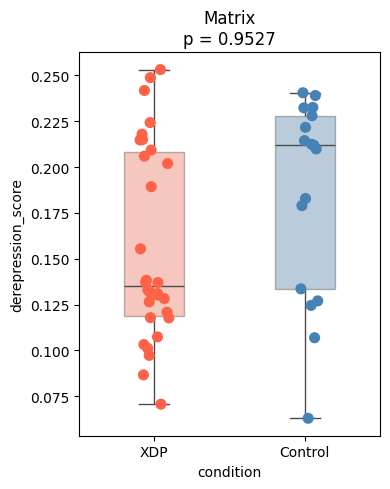

Index(['XDP', 'Control'], dtype='object', name='condition')
ctrl donors: 17, xdp donors: 30
                gene  freq_ctrl  freq_xdp     delta      pval
1             ATP2B4   0.268530  0.494329  0.225799  0.000225
2              GRIA4   0.441764  0.654563  0.212798  0.000505
3              GNAI1   0.447595  0.604198  0.156603  0.003816
4             ATP8B4   0.274387  0.402364  0.127977  0.027737
5    ENSG00000226149   0.117775  0.239429  0.121654  0.000039
..               ...        ...       ...       ...       ...
166           HS3ST1   0.013285  0.024032  0.010748  0.018205
167           CXCL14   0.007463  0.018185  0.010722  0.023585
186          MAL-AS1   0.008271  0.017294  0.009023  0.029790
204           CRABP1   0.006373  0.013638  0.007264  0.027441
213           ELAVL4   0.007716  0.014597  0.006881  0.048356

[62 rows x 5 columns]


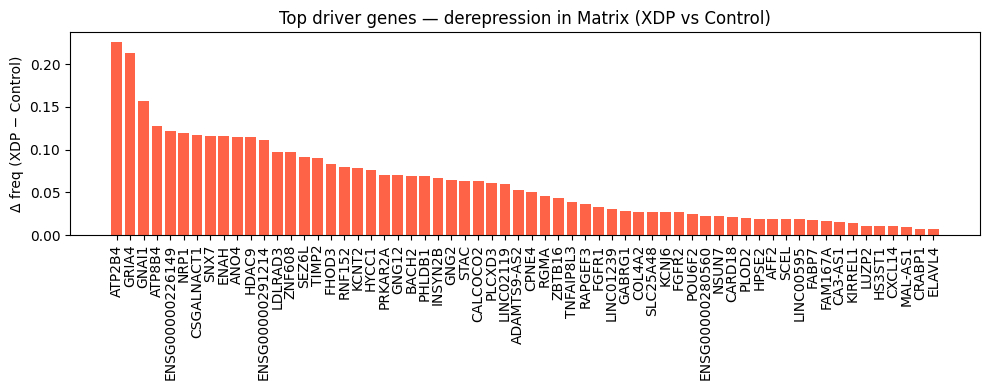

In [31]:
from scipy.stats import mannwhitneyu
import scipy.sparse as sp

# ── 1. Significance test ───────────────────────────────────────────────────────
CT_FOCUS = "Matrix"

matrix_df = derep_df[derep_df["ct"] == CT_FOCUS]
ctrl_scores = matrix_df[matrix_df["condition"] == CONTRAST_BASELINE]["derepression_score"]
xdp_scores  = matrix_df[matrix_df["condition"] == CONTRAST_STIM]["derepression_score"]

stat, pval = mannwhitneyu(xdp_scores, ctrl_scores, alternative="greater")
print(f"Mann-Whitney U (XDP > Control) in {CT_FOCUS}: p = {pval:.4f}  (U = {stat})")

fig, ax = plt.subplots(figsize=(4, 5))
sns.stripplot(data=matrix_df, x="condition", y="derepression_score",
              palette={CONTRAST_BASELINE: "steelblue", CONTRAST_STIM: "tomato"}, size=8, ax=ax)
sns.boxplot(data=matrix_df, x="condition", y="derepression_score",
            palette={CONTRAST_BASELINE: "steelblue", CONTRAST_STIM: "tomato"},
            width=0.4, boxprops=dict(alpha=0.4), ax=ax)
ax.set_title(f"{CT_FOCUS}\np = {pval:.4f}")
plt.tight_layout(); plt.show()

# ── 2. Driver genes (vectorized) ──────────────────────────────────────────────
matrix_cells = adata[adata.obs[CT_COLUMN] == CT_FOCUS]

X_low = matrix_cells.layers["log1p_norm"][:, gene_idx]
if sp.issparse(X_low):
    expressed = (X_low > 0).toarray().astype(float)
else:
    expressed = (X_low > 0).astype(float)

freq_matrix = pd.DataFrame(expressed, index=matrix_cells.obs.index, columns=genes_in_adata)
freq_matrix[SAMPLE_VARIABLE]   = matrix_cells.obs[SAMPLE_VARIABLE].astype(str).values
freq_matrix[CONTRAST_VARIABLE] = matrix_cells.obs[CONTRAST_VARIABLE].astype(str).values

per_donor = freq_matrix.groupby([SAMPLE_VARIABLE, CONTRAST_VARIABLE])[genes_in_adata].mean()

ctrl_donors = per_donor[per_donor.index.get_level_values(CONTRAST_VARIABLE) == CONTRAST_BASELINE]
xdp_donors  = per_donor[per_donor.index.get_level_values(CONTRAST_VARIABLE) == CONTRAST_STIM]
print(per_donor.index.get_level_values(CONTRAST_VARIABLE).unique())
print(f"ctrl donors: {len(ctrl_donors)}, xdp donors: {len(xdp_donors)}")

gene_records = []
for g in genes_in_adata:
    ctrl_g = ctrl_donors[g].dropna()
    xdp_g  = xdp_donors[g].dropna()
    delta  = xdp_g.mean() - ctrl_g.mean()
    p = mannwhitneyu(xdp_g, ctrl_g, alternative="greater").pvalue if (len(xdp_g) > 1 and len(ctrl_g) > 1) else np.nan
    gene_records.append({"gene": g, "freq_ctrl": ctrl_g.mean(), "freq_xdp": xdp_g.mean(), "delta": delta, "pval": p})

gene_df = pd.DataFrame(gene_records).sort_values("delta", ascending=False).reset_index(drop=True)
gene_df_sig = gene_df[gene_df["pval"] < 0.05]
print(gene_df_sig)#.head(20))

# Bar plot top 30 driver genes
top = gene_df_sig #gene_df.head(30)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top["gene"], top["delta"], color="tomato")
ax.set_title(f"Top driver genes — derepression in {CT_FOCUS} (XDP vs Control)")
ax.set_ylabel("Δ freq (XDP − Control)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()


In [32]:
gene_df_sig.gene.tolist()

['ATP2B4',
 'GRIA4',
 'GNAI1',
 'ATP8B4',
 'ENSG00000226149',
 'NRP1',
 'CSGALNACT1',
 'SNX7',
 'ENAH',
 'ANO4',
 'HDAC9',
 'ENSG00000291214',
 'LDLRAD3',
 'ZNF608',
 'SEZ6L',
 'TIMP2',
 'FHOD3',
 'RNF152',
 'KCNT2',
 'HYCC1',
 'PRKAR2A',
 'GNG12',
 'BACH2',
 'PHLDB1',
 'INSYN2B',
 'GNG2',
 'STAC',
 'CALCOCO2',
 'PLCXD3',
 'LINC02119',
 'ADAMTS9-AS2',
 'CPNE4',
 'RGMA',
 'ZBTB16',
 'TNFAIP8L3',
 'RAPGEF3',
 'FGFR1',
 'LINC01239',
 'GABRG1',
 'COL4A2',
 'SLC25A48',
 'KCNJ6',
 'FGFR2',
 'POU6F2',
 'ENSG00000280560',
 'NSUN7',
 'CARD18',
 'PLOD2',
 'HPSE2',
 'AFF2',
 'SCEL',
 'LINC00595',
 'FABP7',
 'FAM167A',
 'CA3-AS1',
 'KIRREL1',
 'LUZP2',
 'HS3ST1',
 'CXCL14',
 'MAL-AS1',
 'CRABP1',
 'ELAVL4']